# Notebook 01: Problem Statement & Exploratory Data Analysis

**Student Name:** Kalpana

**Dataset:** [Craigslist Used Cars Dataset](https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data)

**Checkpoints:**
- Checkpoint 1 (Due Feb 1): Sections 1-3
- Checkpoint 2 (Due Feb 8): Sections 4-6

---

## Rules & Integrity

1. **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, GitHub Copilot, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.

2. **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, share approaches, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own work**.

3. **Use Your Resources**: You are free to use Google, StackOverflow, Pandas/Scikit-learn documentation, and your class notes.

4. **Comment Your Code**: Include comments explaining *why* you're doing what you're doing. I want to see your thought process.

5. **Resubmission**: You may submit this assignment multiple times for feedback before each checkpoint deadline.

---

## Important: Written Reflections

Throughout this notebook, you'll see text cells asking you to explain your decisions, observations, and reasoning. **These written reflections are a critical part of your grade.** 

Don't just write one-word answers or skip these sections. Your reflections demonstrate:
- Your understanding of the data science process
- Your ability to communicate findings to stakeholders
- Your critical thinking about data quality and feature importance

Take time to write thoughtful, complete responses. This is what separates a good data scientist from someone who just runs code!

---

## Setup

Run this cell first to import all necessary libraries.

In [1]:
# Core libraries
import pandas as pd
import numpy as np


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
# pd.set_option('display.float_format', '{:.2f}'.format)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Disable scientific notation on all axes globally
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.limits'] = (-99, 99)

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


---

# CHECKPOINT 1 (Due: Feb 1)

---

## Section 1: Problem Statement

### 1.1 What are you trying to predict?

*Clearly state your target variable and what it represents.*

**Your answer:**

We're trying to predict the used cars sale price using `price` column as a target variable since it represents the used cars sale value.


### 1.2 Why does this prediction matter?

*Who would care about this prediction? What decisions could be made with it?*

**Your answer:**

Sellers, Buyers and dealers care about purchasing strategies. This helps sellers/buyers and dealers set competitive listings, automate pricing, and make inform trade-in or financing decisions. We will come to know market trend analysis. 


### 1.3 What features might help predict the target?

*Based on your intuition and domain knowledge, what columns do you think will be most important?*

**Your answer:**

When sellers/buyers thinking key features are year/make/odometer/condition.


## Section 2: Dataset Overview

### 2.1 Load Your Data

In [2]:
# Load your dataset
# Update the path to match your file name
df = pd.read_csv('../data/raw/vehicles.csv')

# Display basic info
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset shape: 426,880 rows, 26 columns

Column names:
['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'county', 'state', 'lat', 'long', 'posting_date']


In [3]:
# TODO: View the first 5 rows of your dataframe
#
# Hint: Use .head()

# YOUR CODE HERE:
df.head(5)

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [4]:
# TODO: View the last 5 rows of your dataframe
#
# Hint: Use .tail()

# YOUR CODE HERE:
df.tail(5)

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600
426879,7301591129,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,gas,22716.0,clean,other,WBA4J1C58KBM14708,rwd,NaN,coupe,NaN,https://images.craigslist.org/00Y0Y_lEUocjyRxa...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:07-0600


### 2.2 Data Types and Info

In [5]:
# TODO: Display info about your dataframe (data types, non-null counts)
#
# Hint: Use .info()

# YOUR CODE HERE:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [6]:
# TODO: Get summary statistics for numerical columns
#
# Hint: Use .describe()


# YOUR CODE HERE:

df[['price', 'odometer']].info()

# convert price and odometer to numeric without using scientific notation
df['price'] = df['price'].astype('Int64')
df['odometer'] = df['odometer'].astype('Float64')

df[['price', 'odometer']].info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   price     426880 non-null  int64  
 1   odometer  422480 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 6.5 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   price     426880 non-null  Int64  
 1   odometer  422480 non-null  Float64
dtypes: Float64(1), Int64(1)
memory usage: 7.3 MB


,id,price,year,odometer,county,lat,long
count,4.268800e+05,426880.0,425675.000000,422480.0,0.0,420331.000000,420331.000000
mean,7.311487e+09,75199.033187,2011.235191,98043.331443,NaN,38.493940,-94.748599
std,4.473170e+06,12182282.173598,9.452120,213881.500798,NaN,5.841533,18.365462
min,7.207408e+09,0.0,1900.000000,0.0,NaN,-84.122245,-159.827728
25%,7.308143e+09,5900.0,2008.000000,37704.0,NaN,34.601900,-111.939847
50%,7.312621e+09,13950.0,2013.000000,85548.0,NaN,39.150100,-88.432600
75%,7.315254e+09,26485.75,2017.000000,133542.5,NaN,42.398900,-80.832039
max,7.317101e+09,3736928711.0,2022.000000,10000000.0,NaN,82.390818,173.885502


In [7]:
# TODO: Get summary statistics for categorical columns
#
# Hint: Use .describe(include='object')

# YOUR CODE HERE
df.describe(include='object')

,url,region,region_url,manufacturer,model,condition,cylinders,fuel,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,state,posting_date
count,426880,426880,426880,409234,421603,252776,249202,423867,418638,424324,265838,296313,120519,334022,296677,426812,426810,426880,426812
unique,426880,404,413,42,29667,6,8,5,6,3,118264,3,4,13,12,241899,360911,51,381536
top,https://prescott.craigslist.org/cto/d/prescott...,columbus,https://spokane.craigslist.org,ford,f-150,good,6 cylinders,gas,clean,automatic,1FMJU1JT1HEA52352,4wd,full-size,sedan,white,https://images.craigslist.org/00N0N_1xMPvfxRAI...,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,ca,2021-04-23T22:13:05-0400
freq,1,3608,2988,70985,8009,121456,94169,356209,405117,336524,261,131904,63465,87056,79285,7357,231,50614,12


### 2.3 Dataset Description

*After looking at the data above, describe your dataset in your own words.*

**Questions to answer:**
1. Where did this data come from? (Kaggle link, source)
2. What does each row represent?
3. How many features do you have?
4. What types of features do you have? (numerical, categorical)

**Your description:**
1. The dataset comes from Kaggle and source link is https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data
2. Each row represents the used cars details like model, image_url, mileage, type, manufacturer, condition, title_status and so on.
3. There are total of 26 columns as features.
4. Numerical columns are 7, Categorical columns are 19.


## Section 3: Initial EDA

### 3.1 Target Variable Analysis

In [8]:
# Define your target variable
TARGET = 'price'  # <-- set target variable

# Basic statistics of target
print(f"Target Variable: {TARGET}")
print(f"\nBasic Statistics:")
print(df[TARGET].describe())

Target Variable: price

Basic Statistics:
count           426880.0
mean        75199.033187
std      12182282.173598
min                  0.0
25%               5900.0
50%              13950.0
75%             26485.75
max         3736928711.0
Name: price, dtype: Float64


In [9]:
#How to fill missing values in the target variable?
missing_target = df[TARGET].isnull().sum()
print(f"\nMissing values in target: {missing_target}") 

df[TARGET].fillna(df[TARGET].median(), inplace=True)

print(f"Missing values after imputation: {df[TARGET].isnull().sum()}") 
df[TARGET].describe()
df


Missing values in target: 0
Missing values after imputation: 0


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600


In [10]:
#TODO: Treat zeros as missing values in the target variable if it makes sense for your dataset.
# Hint: Use .replace() to replace zeros with np.nan, then impute as needed.

df[TARGET] = df[TARGET].replace(0, np.nan)
missing_target = df[TARGET].isnull().sum()
print(f"\nMissing values in target after replacing zeros: {missing_target}") 
df[TARGET].fillna(df[TARGET].median(), inplace=True)
print(f"Missing values after imputation: {df[TARGET].isnull().sum()}") 
df[TARGET].describe()


Missing values in target after replacing zeros: 32895
Missing values after imputation: 0


count           426880.0
mean        76354.920088
std      12182275.695282
min                  1.0
25%               7900.0
50%              15000.0
75%             26485.75
max         3736928711.0
Name: price, dtype: Float64

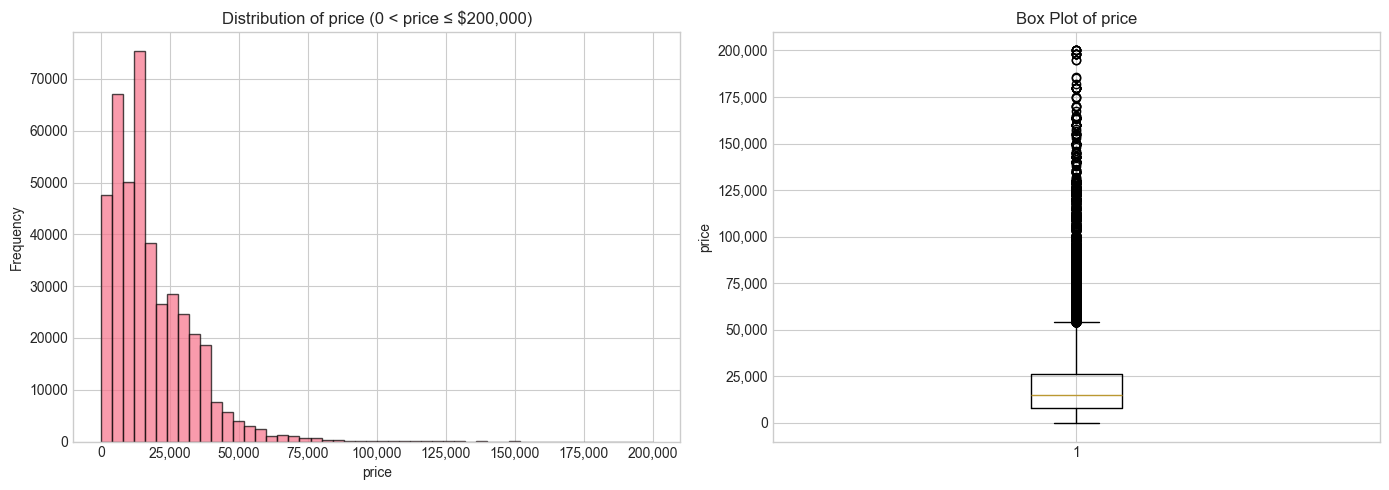

Removed 124 outliers and used 426,756 of 426,880 rows

Skewness: 1.77
→ Target is highly skewed. Consider log transform in feature engineering.


In [11]:
# Distribution of target variable
import matplotlib.ticker as ticker

# For visualization purposes, use ONLY rows with real (non-imputed) prices.
# Filter out the zero/missing prices AND extreme outliers.
df_price_clean = df[TARGET].dropna()
df_price_clean = df_price_clean[(df_price_clean > 0) & (df_price_clean <= 200000)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with more bins to see the real shape
axes[0].hist(df_price_clean, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Distribution of {TARGET} (0 < price ≤ $200,000)')
# Format x-axis labels without scientific notation
axes[0].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Box plot
axes[1].boxplot(df_price_clean)
axes[1].set_ylabel(TARGET)
axes[1].set_title(f'Box Plot of {TARGET}')
# Format y-axis labels without scientific notation
axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

# Statistics and skewness on the clean data
print(f"Removed {len(df) - len(df_price_clean):,} outliers and used {len(df_price_clean):,} of {len(df):,} rows")
skewness = df_price_clean.skew()
print(f"\nSkewness: {skewness:.2f}")
if abs(skewness) > 1:
    print("→ Target is highly skewed. Consider log transform in feature engineering.")
elif abs(skewness) > 0.5:
    print("→ Target is moderately skewed.")
else:
    print("→ Target is approximately symmetric.")

### 3.2 Data Quality Checks

In [12]:

# TODO: Check for duplicate rows in your dataframe
#
# Steps:
# 1. Count how many duplicate rows exist using df.duplicated().sum()
# 2. Print the count and the percentage of duplicates
#
# Expected output format:
# "Duplicate rows: X,XXX (X.XX%)"

# YOUR CODE HERE:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100
print(f"Duplicate rows: {duplicate_count:,} ({duplicate_percentage:.2f}%)")

Duplicate rows: 0 (0.00%)


In [13]:
# TODO: Create a summary of missing values
#
# Steps:
# 1. Calculate missing count for each column: df.isnull().sum()
# 2. Calculate missing percentage: (df.isnull().sum() / len(df)) * 100
# 3. Create a DataFrame with 'Missing Count' and 'Missing %' columns
# 4. Sort by 'Missing %' descending
# 5. Display only columns that have missing values
#
# Hint: You can create a DataFrame with pd.DataFrame({'col1': series1, 'col2': series2})

# YOUR CODE HERE:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_percentage})
missing_df = missing_df[missing_df['Missing Count'] > 0]
missing_df = missing_df.sort_values(by='Missing %', ascending=False)
missing_df


,Missing Count,Missing %
county,426880,100.000000
size,306361,71.767476
cylinders,177678,41.622470
condition,174104,40.785232
VIN,161042,37.725356
drive,130567,30.586347
paint_color,130203,30.501078
type,92858,21.752717
manufacturer,17646,4.133714
title_status,8242,1.930753


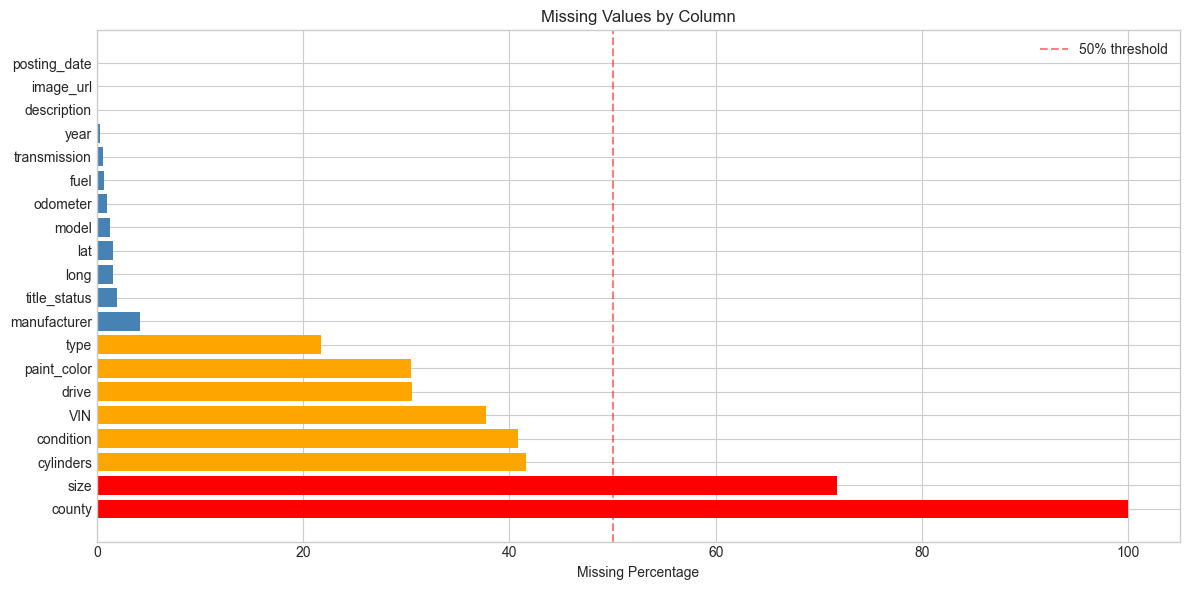


⚠️ Columns with >50% missing (consider dropping): ['county', 'size']


In [14]:
# Visualize missing values (if any)
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_cols = missing_df[missing_df['Missing Count'] > 0]
    colors = ['red' if pct > 50 else 'orange' if pct > 20 else 'steelblue' 
              for pct in missing_cols['Missing %']]
    plt.barh(missing_cols.index, missing_cols['Missing %'], color=colors)
    plt.xlabel('Missing Percentage')
    plt.title('Missing Values by Column')
    plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Recommendation
    high_missing = missing_cols[missing_cols['Missing %'] > 50]
    if len(high_missing) > 0:
        print(f"\n⚠️ Columns with >50% missing (consider dropping): {high_missing.index.tolist()}")
else:
    print("✓ No missing values in the dataset!")

### 3.3 Initial Observations

*Based on your initial exploration, what do you notice?*

**Questions to consider:**

1. Is your target variable normally distributed or skewed?

2. Are there any obvious outliers in the target?

3. How much missing data do you have to deal with?
  
4. Are there any duplicate rows?

5. Any surprises or interesting findings?



**Your observations:**

[Write your observations here]

1. Its highly skewed. Many price columns are zero. 

2. Yes, there Price columns have many zero values and also has extreme value like 3.736929e+09

3. Total missing cells: 1,655,336.
   
   Top missing percentages (highest first):

   ```text
   county: 100.0%
   size: 71.77%
   cylinders: 41.62%
   condition: 40.79%
   VIN: 37.73%
   drive: 30.59%
   paint_color: 30.50%
   type: 21.75%
   manufacturer: 4.13%
   title_status: 1.93%
   ```

   Columns >50% missing: size, county (consider dropping).
  
4. There are 0 duplicate rows.

5. Large max price and enormous skew indicate bad or mis-scaled values — investigate units or corrupt rows.

   Many zero-priced listings — decide whether zeros represent valid listings, auctions, or missing/placeholder values.
   
   Several important features have high missingness (size, county) which may need dropping or careful imputation.

---

## ✅ Checkpoint 1 Submission Instructions

**Congratulations!** You've completed Checkpoint 1. Before moving on, let's commit your work and submit.

### Step 1: Save This Notebook
- File → Save (or Ctrl+S / Cmd+S)

### Step 2: Commit to GitHub
Open your terminal and run these commands:

```bash
# Navigate to your project folder (if not already there)
cd path/to/your/capstone-project

# Stage your notebook and data
git add notebooks/01_problem_statement_and_eda.ipynb
git add data/raw/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 1: Problem statement and initial EDA"

# Push to GitHub
git push
```

### Step 3: Submit to Canvas
1. Go to the Checkpoint 1 assignment on Canvas
2. Submit the link to your GitHub repository
3. Make sure your repo shows your latest commit!

### Step 4: Continue to Checkpoint 2
Now proceed to **Section 4** below to continue with your complete EDA, data cleaning, and feature engineering.

---

---

# CHECKPOINT 2 (Due: Feb 8)

---

## Section 4: Complete EDA

### 4.1 Numerical Features Analysis

In [15]:
# TODO: Get a list of numerical columns (excluding the target)
#
# Steps:
# 1. Use df.select_dtypes(include=[np.number]) to get numerical columns
# 2. Get the column names as a list with .columns.tolist()
# 3. Remove TARGET from the list if it's in there
# 4. Print the count and list of numerical features
#
# Store result in: numerical_cols

# YOUR CODE HERE:

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if TARGET in numerical_cols:
    numerical_cols.remove(TARGET)

print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")

Numerical features (6): ['id', 'year', 'odometer', 'county', 'lat', 'long']


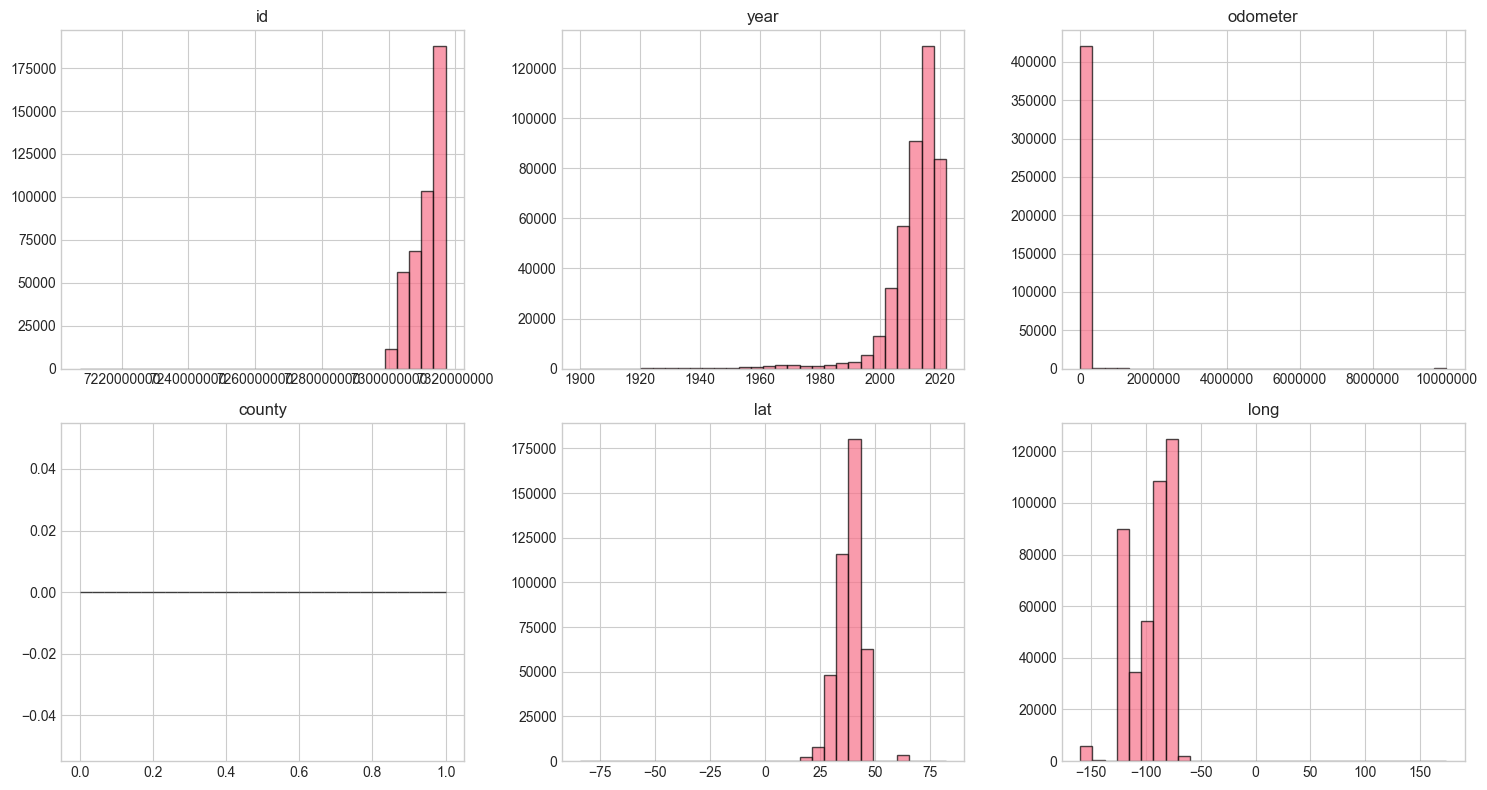

In [16]:
# Distribution of numerical features
if len(numerical_cols) > 0:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes

    for i, col in enumerate(numerical_cols):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        # Remove scientific notation on both axes
        # axes[i].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
        # axes[i].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    # Hide empty subplots
    for j in range(len(numerical_cols), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical features found (besides target).")

### 4.2 Categorical Features Analysis

In [17]:
# TODO: Get a list of categorical columns and explore their values
#
# Steps:
# 1. Use df.select_dtypes(include=['object', 'category']) to get categorical columns
# 2. Get the column names as a list
# 3. Print the count and list of categorical features
# 4. For each categorical column, print:
#    - Number of unique values: df[col].nunique()
#    - Top 10 value counts: df[col].value_counts().head(10)
#
# Store result in: categorical_cols

# YOUR CODE HERE:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

for col in categorical_cols:
    print(f"\nColumn Name: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print(f"Top 10 value counts: {df[col].value_counts().head(10)}")

Categorical features (19): ['url', 'region', 'region_url', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'state', 'posting_date']

Column Name: url
Number of unique values: 426880
Top 10 value counts: url
https://prescott.craigslist.org/cto/d/prescott-2010-ford-ranger/7222695916.html             1
https://nh.craigslist.org/cto/d/troy-1998-dodge-ram-59-cummins/7313139418.html              1
https://nh.craigslist.org/ctd/d/north-hampton-2012-hyundai-sante-fe-se/7313423023.html      1
https://nh.craigslist.org/ctd/d/derry-2008-chrysler-sebring-limited-all/7313423324.html     1
https://nh.craigslist.org/ctd/d/derry-2002-toyota-camry-low-miles/7313424533.html           1
https://nh.craigslist.org/ctd/d/derry-2008-hyundai-accent-only-50k-miles/7313425823.html    1
https://nh.craigslist.org/ctd/d/hampton-2016-chevy-chevrolet-express/7313426990.html        1
https://nh.craigs

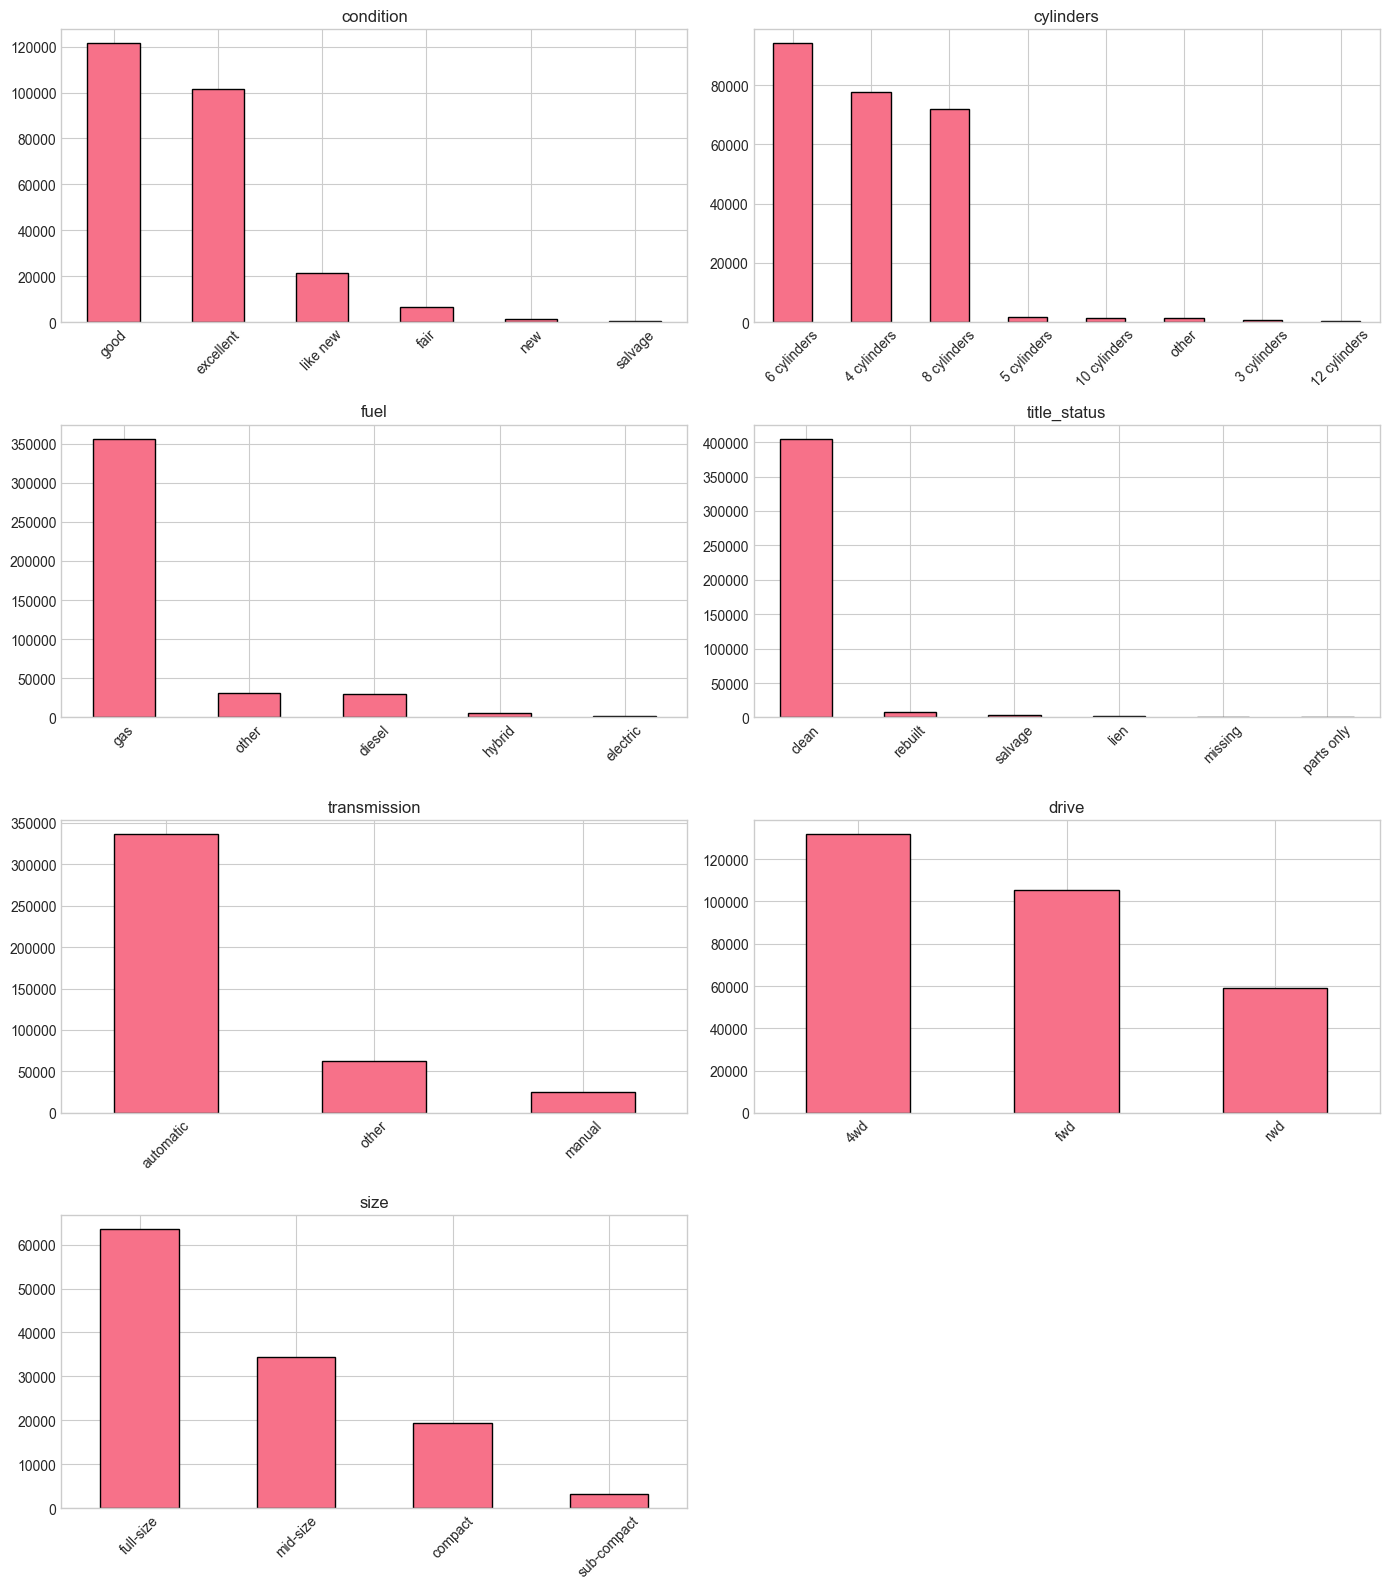

In [18]:
# Visualize categorical features (for columns with reasonable number of categories)
cat_cols_to_plot = [col for col in categorical_cols if df[col].nunique() <= 10]

if cat_cols_to_plot:
    n_cols = 2
    n_rows = (len(cat_cols_to_plot) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if len(cat_cols_to_plot) == 1 else axes
    
    for i, col in enumerate(cat_cols_to_plot):
        df[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
    
    # Hide empty subplots
    for j in range(len(cat_cols_to_plot), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns with ≤10 unique values to plot.")

### 4.3 Categorical Features vs Target

*How does the target variable differ across categories?*

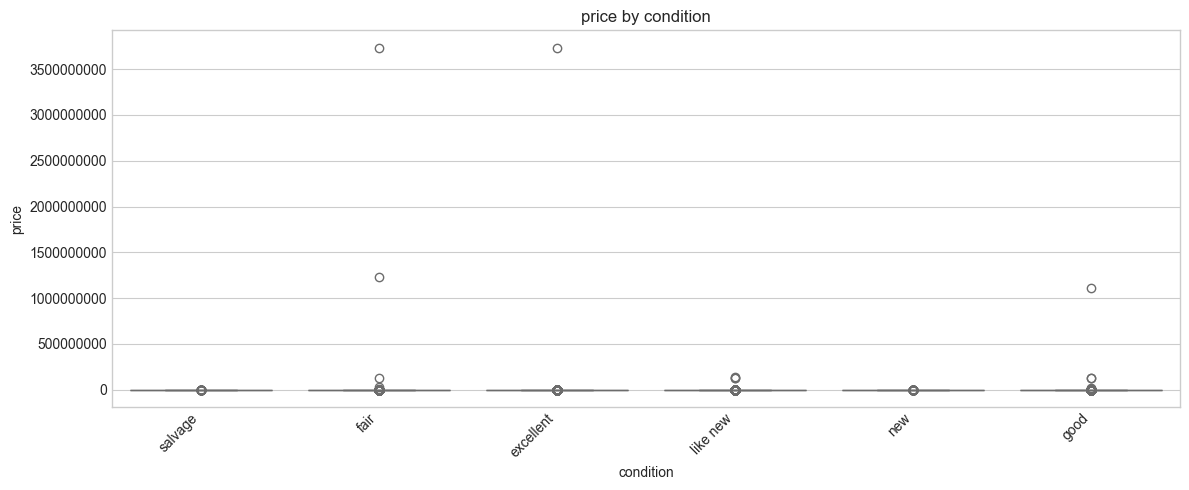


Mean price by condition:
                    mean   median   count
condition                                
fair       761178.644999   2800.0    6769
excellent   52313.938413  12900.0  101467
like new    37193.901454  15000.0   21178
good        32829.380088  19995.0  121456
new         25645.772414  15900.0    1305
salvage      3755.284526   1890.0     601



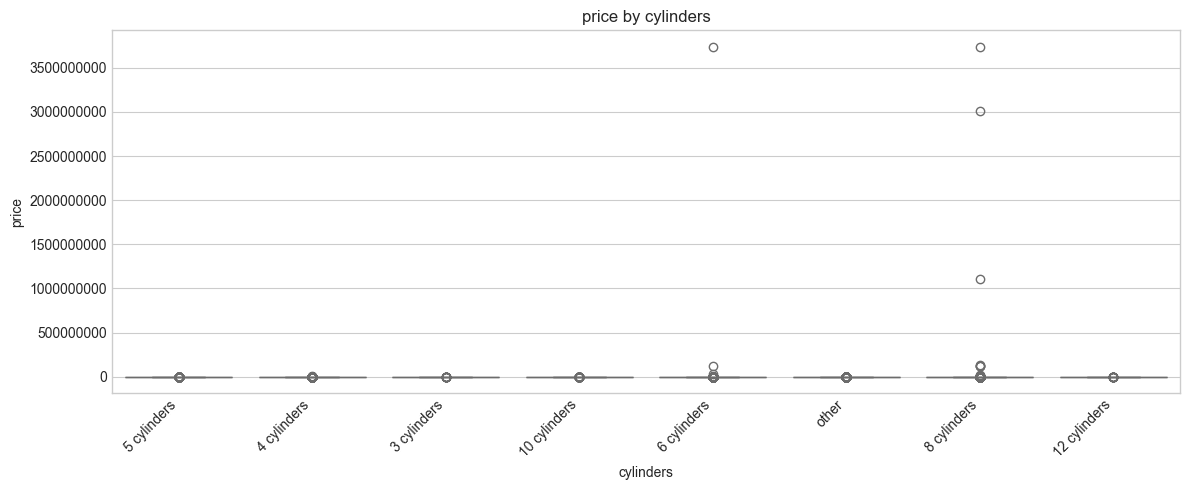


Mean price by cylinders:
                       mean   median  count
cylinders                                  
8 cylinders   140698.522508  18900.0  72062
6 cylinders    59544.048264  15000.0  94169
12 cylinders    54658.23445  28990.0    209
10 cylinders   22188.214433  15000.0   1455
other          19594.669492  15000.0   1298
3 cylinders    13258.829008  10295.0    655
4 cylinders    11441.143827   9800.0  77642
5 cylinders     8210.770444   6500.0   1712



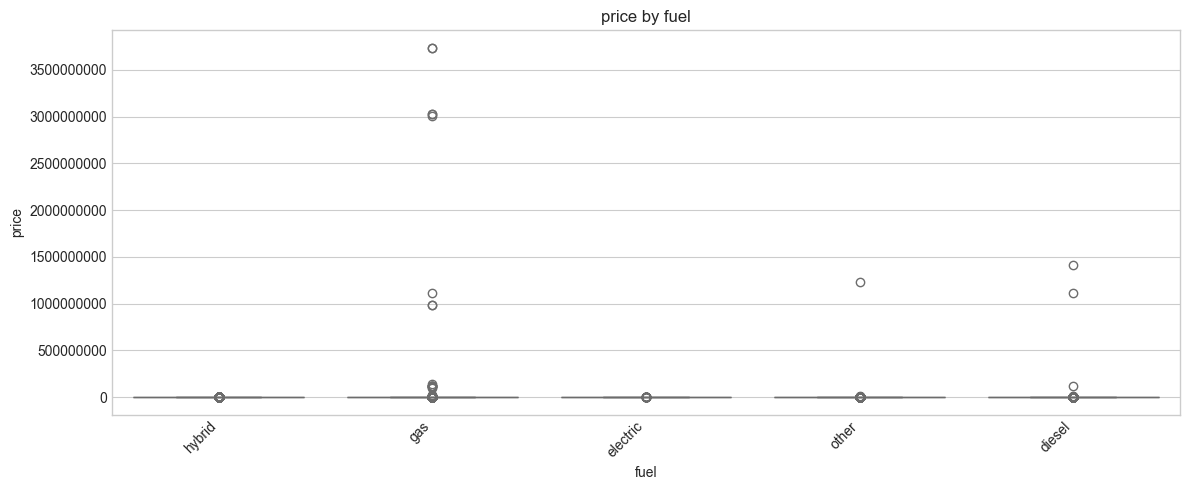


Mean price by fuel:
                   mean   median   count
fuel                                    
diesel    120043.337802  27990.0   30062
gas        74987.774062  14990.0  356209
other       68082.06909  25990.0   30728
electric   25284.404594  22544.5    1698
hybrid     15406.415474  13590.0    5170



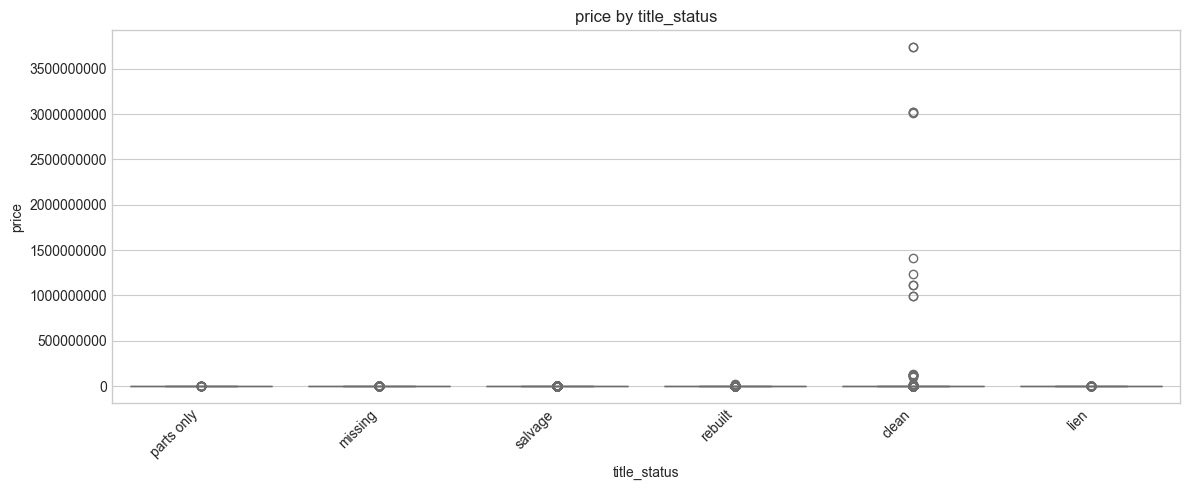


Mean price by title_status:
                      mean   median   count
title_status                               
clean          79637.87669  15000.0  405117
lien          22434.552743  17877.5    1422
missing       21963.577396   2800.0     814
rebuilt       15257.162072  10500.0    7219
parts only    12185.318182   1325.0     198
salvage       10389.486298   7495.0    3868



In [19]:
# Box plots: Target by categorical features
cat_cols_to_analyze = [col for col in categorical_cols if df[col].nunique() <= 8]

if cat_cols_to_analyze:
    for col in cat_cols_to_analyze[:4]:  # Limit to first 4 for readability
        plt.figure(figsize=(12, 5))
        
        # Order by median target value
        order = df.groupby(col)[TARGET].median().sort_values().index
        
        sns.boxplot(data=df, x=col, y=TARGET, order=order)
        plt.title(f'{TARGET} by {col}')
        plt.xticks(rotation=45, ha='right')
        # Remove scientific notation on the price (y) axis
        # plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
        plt.tight_layout()
        plt.show()
        
        # Show mean target by category
        print(f"\nMean {TARGET} by {col}:")
        print(df.groupby(col)[TARGET].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False))
        print("\n" + "="*50)
else:
    print("No suitable categorical columns for this analysis.")

### 4.4 Correlation Analysis

List of columns: ['id', 'year', 'odometer', 'county', 'lat', 'long', 'price']


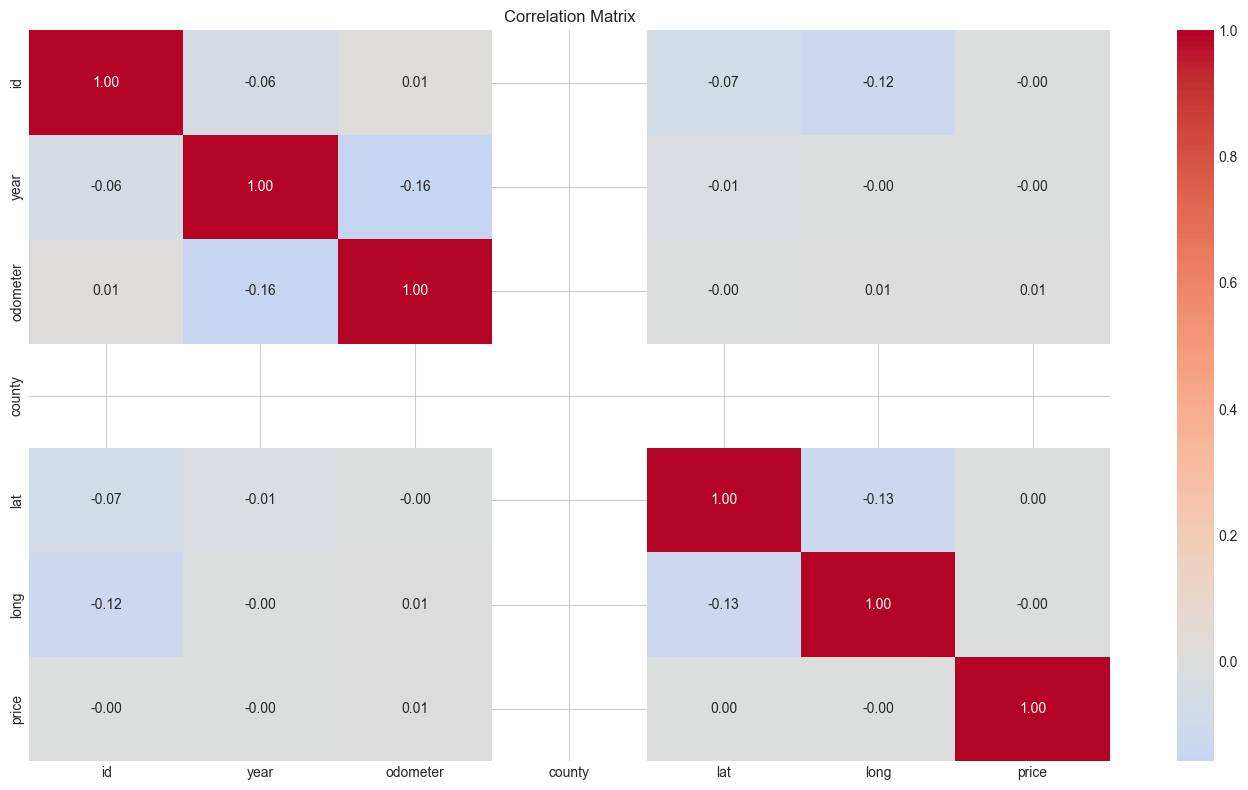

In [20]:
# TODO: Create and visualize a correlation matrix
#
# Steps:
# 1. Create a list of columns: numerical_cols + [TARGET]
# 2. Calculate the correlation matrix: df[columns].corr()
# 3. Create a heatmap using sns.heatmap()
#
# Heatmap parameters to use:
# - annot=True (show numbers)
# - cmap='coolwarm' (color scheme)
# - center=0 (center colormap at 0)
# - fmt='.2f' (2 decimal places)
#
# Store the correlation matrix in: correlation_matrix

# YOUR CODE HERE:
columns = numerical_cols + [TARGET]
print(f"List of columns: {columns}")

# For better heatmamp visualization, 
# Removing the 'id' since it is just id and not going to provide meaningful insight when it comes correlation.
# Removing the 'county' column because it contains only missing/empty values across all rows.
# columns.remove("id")
# columns.remove("county")
# print(f"List of columns: {columns}")

correlation_matrix = df[columns].corr()

plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [21]:
# TODO: Extract and analyze correlations with the target variable
#
# Steps:
# 1. Get the TARGET column from correlation_matrix
# 2. Drop the TARGET's correlation with itself (it's always 1.0)
# 3. Sort values in descending order
# 4. Print the correlations
# 5. Identify strong correlations (absolute value > 0.5)
#
# Store result in: target_correlations

# YOUR CODE HERE:
target_correlations = correlation_matrix[TARGET].drop(TARGET).sort_values(ascending=False)

print("Correlations with TARGET:")
print(target_correlations)

strong_correlations = target_correlations[abs(target_correlations) > 0.5]
if len(strong_correlations) > 0:
    print(f"\nStrong correlations (|r| > 0.5): {len(strong_correlations)}")
    print(strong_correlations)
else:
    print(f"\nNo strong correlations w.r.t '{TARGET}' target variable!")

Correlations with TARGET:
odometer    0.010029
lat         0.000353
long       -0.000427
id         -0.002778
year       -0.004898
county           NaN
Name: price, dtype: float64

No strong correlations w.r.t 'price' target variable!


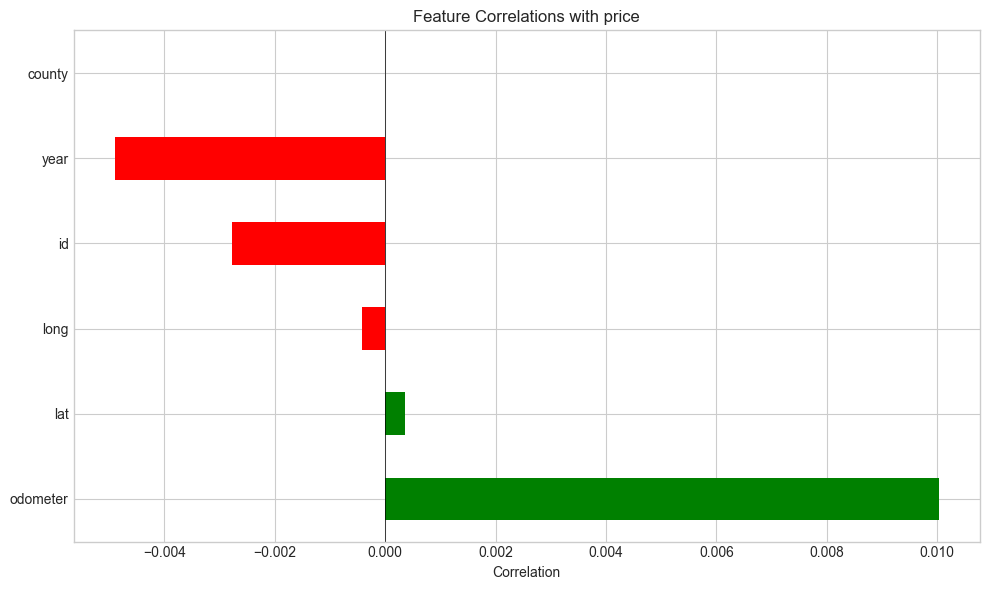

In [22]:
# Visualize correlations with target
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in target_correlations]
target_correlations.plot(kind='barh', color=colors)
plt.xlabel('Correlation')
plt.title(f'Feature Correlations with {TARGET}')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

### 4.5 Feature vs Target Relationships

*Create scatter plots for your most promising numerical features against the target.*

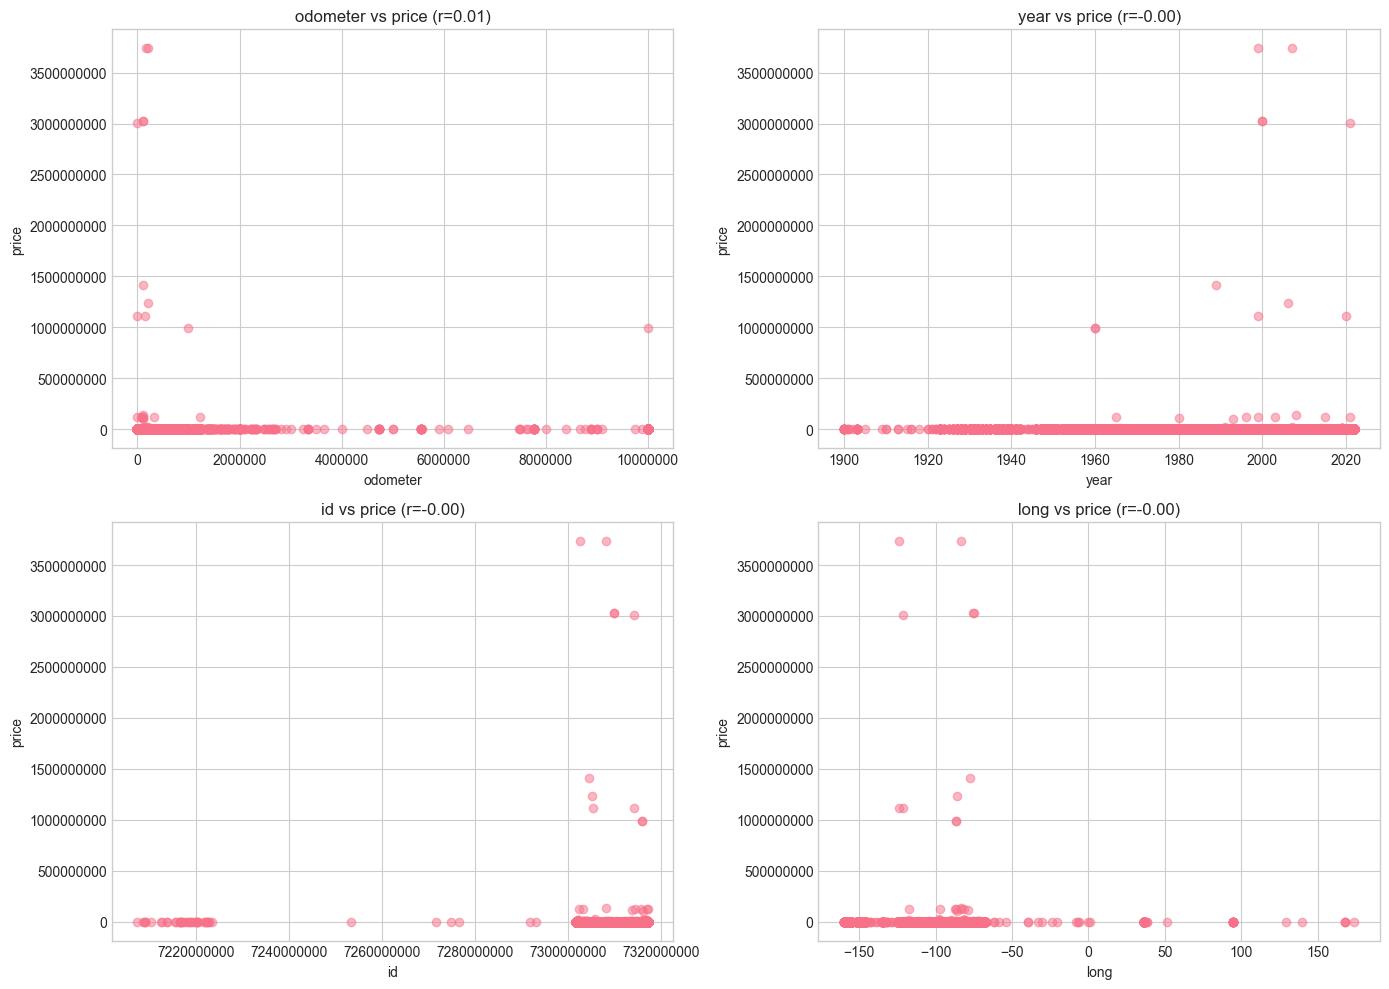

In [23]:
# Select top correlated features to plot
top_features = target_correlations.abs().sort_values(ascending=False).head(4).index.tolist()

if len(top_features) > 0:
    n_features = min(4, len(top_features))
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, feature in enumerate(top_features[:n_features]):
        axes[i].scatter(df[feature], df[TARGET], alpha=0.5)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(TARGET)
        corr = df[feature].corr(df[TARGET])
        axes[i].set_title(f'{feature} vs {TARGET} (r={corr:.2f})')
        # Remove scientific notation on both axes
        # axes[i].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
        # axes[i].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    # Hide unused subplots
    for j in range(n_features, 4):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical features to plot.")

### 4.6 Additional Exploration (Your Choice!)

The sections above provide a foundation, but every dataset is unique. Use the cells below to explore additional aspects of YOUR data that you think are important.

**Ideas for additional exploration:**
- Violin plots for categorical vs target (shows distribution shape)
- Look at feature interactions (e.g., does the relationship between X and Y change based on Z?)
- Explore geographic patterns (if you have location data)
- Create pair plots for key features (`sns.pairplot()`)
- Analyze distributions across different subgroups
- Look for data quality issues specific to your dataset
- Check for nonsensical values (negative prices, impossible ages, etc.)

**Remember:** The best insights often come from curiosity-driven exploration, not just following a template. What questions do YOU have about your data?

In [24]:
# YOUR ADDITIONAL EDA CODE HERE
# Add as many cells as you need - don't be limited by this template!
# For example, you could:
# - Explore interactions between features
# - Create new features based on domain knowledge
# - Analyze outliers in more detail  
# Look at feature interactions with strong correlations to the target
# YOUR CODE HERE:

# 


In [25]:
# More exploration...

**What additional insights did you discover?**

[Describe any additional findings from your custom exploration


### 4.7 EDA Insights Summary

*Summarize your key findings from the EDA.*

**Questions to answer:**
- Which features are most correlated with your target?
- Which categorical features show the biggest differences in target?
- Are there any features that seem unimportant?
- Did you discover any interesting patterns or relationships?
- Are there any concerns about the data (outliers, skewness, etc.)?

**Your summary:**

[Write your summary here]

1. Based on the correlation matrix, there are no features strongly correlated with price.

2. cylinders, type, and manufacturer show the biggest price discrimination among categorical features. 
   Cylinders: Huge spread — 4-cylinder cars are much cheaper than 8 or 12-cylinder vehicles.
   Type: Trucks, pickups, and SUVs command significantly higher prices than sedans, hatchbacks, and minis.
   Manufacturer: Premium brands (e.g., Tesla, Ferrari) vs budget brands (e.g., Kia, Hyundai) create large price gaps

3. id, url, region_url, region, county ,lat, long, paint color, size are unimportant interms of value missing, same value, zero value.

4. I think year, odometer got interesting patterns as year is decreasing and odometer is increasing then price is decreasing.

5. Price, year, odometer, long, id got most outliers , price is extremely skewed due to values ranging from $0 to billions due to data entry errors.

## Section 5: Data Cleaning

### 5.1 Decide What to Drop

Before cleaning, decide which columns to remove entirely.

In [26]:
# TODO: Create a copy of your dataframe for cleaning
#
# Why? We want to preserve the original data in case we need to go back.
# Never modify your original dataframe directly!
#
# Store in: df_clean

# YOUR CODE HERE:
df_clean = df.copy()

print(f"Starting shape: {df_clean.shape}")

Starting shape: (426880, 26)


In [27]:
# Identify columns to potentially drop
print("Columns to consider dropping:")
print("="*50)

# 1. High missing rate
high_missing = missing_df[missing_df['Missing %'] > 50].index.tolist()
print(f"\n1. >50% missing values: {high_missing}")

# 2. ID/index columns (no predictive value)
potential_ids = [col for col in df_clean.columns 
                 if 'id' in col.lower() or 'index' in col.lower() or 'url' in col.lower()]
print(f"\n2. Potential ID/URL columns: {potential_ids}")

# 3. High cardinality categorical (too many unique values)
high_cardinality = [col for col in categorical_cols if df_clean[col].nunique() > 100]
print(f"\n3. High cardinality (>100 unique): {high_cardinality}")

# 4. Low variance (same value in most rows)
# Guard against columns with all-missing values which would make value_counts() empty
low_variance = []
for col in df_clean.columns:
    vc = df_clean[col].value_counts(normalize=True)
    if vc.empty:
        # skip columns with all-missing values
        continue
    if vc.iloc[0] > 0.95:
        low_variance.append(col)

print(f"\n4. Low variance (>95% same value): {low_variance}")

Columns to consider dropping:

1. >50% missing values: ['county', 'size']

2. Potential ID/URL columns: ['id', 'url', 'region_url', 'image_url']

3. High cardinality (>100 unique): ['url', 'region', 'region_url', 'model', 'VIN', 'image_url', 'description', 'posting_date']

4. Low variance (>95% same value): ['title_status']


In [28]:
# Drop columns
# TODO: Decide which columns to drop based on the analysis above
# IMPORTANT: Don't just copy all suggestions - think about each one!

columns_to_drop = [
    # Add column names to drop here, e.g.:
    # 'id',
    # 'url',
    *high_missing,  # Drop columns with >50% missing values
    *potential_ids,  # Drop potential ID/URL columns
    *high_cardinality,  # Drop high cardinality categorical columns
    *low_variance  # Drop low variance columns identified earlier
]
columns_to_drop = list(set(columns_to_drop))  # Remove duplicates if any

if columns_to_drop:
    df_clean = df_clean.drop(columns=columns_to_drop)
    print(f"Dropped {len(columns_to_drop)} columns: {columns_to_drop}")
    print(f"New shape: {df_clean.shape}")
else:
    print("No columns dropped. Update the list above if needed.")

Dropped 12 columns: ['description', 'posting_date', 'id', 'url', 'size', 'image_url', 'region', 'model', 'VIN', 'title_status', 'region_url', 'county']
New shape: (426880, 14)


**Explain which columns you dropped and why:**

I dropped the below columns following the reason based on the above analysis: 

1. ['county', 'size'] due to missing values in these columns are >50%
2. ['id', 'url', 'region_url', 'image_url'] due to potential ID/URL columns which are not helpful ML models 
3. ['url', 'region', 'region_url', 'model', 'VIN', 'image_url', 'description', 'posting_date'] due to high cardinality (>100 unique)
4. ['title_status'] due to low variance (i-e: having >95% same value)

### 5.2 Handle Duplicate Rows

In [29]:
# TODO: Remove duplicate rows from df_clean
#
# Steps:
# 1. Store the row count before: len(df_clean)
# 2. Use df_clean.drop_duplicates() to remove duplicates (assign back to df_clean)
# 3. Store the row count after
# 4. Print how many duplicates were removed

# YOUR CODE HERE:
before_count = len(df_clean)
df_clean = df_clean.drop_duplicates()
after_count = len(df_clean)
duplicates_removed = before_count - after_count

print(f"Duplicate rows removed: {duplicates_removed:,}")
print(f"New shape after removing duplicates: {df_clean.shape}")

Duplicate rows removed: 99,258
New shape after removing duplicates: (327622, 14)


### 5.3 Handle Missing Values

In [30]:
# Check missing values in cleaned dataframe
print("Missing values before handling:")
missing_now = df_clean.isnull().sum()
missing_now = missing_now[missing_now > 0].sort_values(ascending=False)
print(missing_now)

Missing values before handling:
cylinders       132161
condition       115134
drive           100433
paint_color      93117
type             70272
manufacturer     14110
lat               2915
long              2915
odometer          2652
fuel              1864
transmission      1596
year               869
dtype: int64


In [31]:
df_clean[TARGET] = df_clean[TARGET].replace(0, np.nan)
missing_target = df_clean[TARGET].isnull().sum()
print(f"\nMissing values in target after replacing zeros: {missing_target}")


Missing values in target after replacing zeros: 0


In [32]:
# Handle missing values
# TODO: Add your missing value handling code here
# 
# STRATEGIES:
# - Numerical columns: use median (robust to outliers) or mean
# - Categorical columns: use mode or 'Unknown'
# - Drop rows if missing target variable
#
# Examples:
# df_clean['column'] = df_clean['column'].fillna(df_clean['column'].median())
# df_clean['column'] = df_clean['column'].fillna('Unknown')
# df_clean = df_clean.dropna(subset=[TARGET])  # Don't predict with missing target!

# YOUR CODE HERE:

df_clean.info()

# Impute numerical columns with median
for col in numerical_cols:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Impute categorical columns with mode
for col in categorical_cols:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])


# Drop rows if missing target variable
df_clean[TARGET] = df_clean[TARGET].replace(0, np.nan)
missing_target = df_clean[TARGET].isnull().sum()
print(f"\nMissing values in target after replacing zeros: {missing_target}")

if missing_target > 0:
    print(f"Dropping {missing_target} rows with missing target variable...")
    df_clean = df_clean.dropna(subset=[TARGET])
else:
    print("No missing values in target variable after handling.\n")

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 327622 entries, 0 to 426879
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         327622 non-null  Int64  
 1   year          326753 non-null  float64
 2   manufacturer  313512 non-null  object 
 3   condition     212488 non-null  object 
 4   cylinders     195461 non-null  object 
 5   fuel          325758 non-null  object 
 6   odometer      324970 non-null  Float64
 7   transmission  326026 non-null  object 
 8   drive         227189 non-null  object 
 9   type          257350 non-null  object 
 10  paint_color   234505 non-null  object 
 11  state         327622 non-null  object 
 12  lat           324707 non-null  float64
 13  long          324707 non-null  float64
dtypes: Float64(1), Int64(1), float64(3), object(9)
memory usage: 38.1+ MB

Missing values in target after replacing zeros: 0
No missing values in target variable after handling.

<class 'pa

In [33]:
# Verify missing values are handled
remaining_missing = df_clean.isnull().sum().sum()
print(f"Missing values after cleaning: {remaining_missing}")

if remaining_missing > 0:
    print("\n⚠️ Still have missing values in:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values after cleaning: 0


**Explain your missing value strategy:**

[Describe what you did for each column and why]


I dropped the rows where the price is missing because price is the target variable and it is not possible to predict the price without the actual price. 

I filled price_missing with mean of the price column.

I filled numeric columns with mean and categorical columns with mode.

### 5.4 Handle Outliers (if needed)

In [34]:
# Check for outliers using IQR method
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = len(data[(data[column] < lower_bound) | (data[column] > upper_bound)])
    return n_outliers, lower_bound, upper_bound

# Get current numerical columns
current_numerical = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print("Outlier analysis:")
print("="*60)
for col in current_numerical:
    n_outliers, lower, upper = find_outliers_iqr(df_clean, col)
    if n_outliers > 0:
        pct = n_outliers / len(df_clean) * 100
        print(f"{col}: {n_outliers:,} outliers ({pct:.1f}%) | bounds: [{lower:.2f}, {upper:.2f}]")

Outlier analysis:
price: 6,246 outliers (1.9%) | bounds: [-21135.00, 55225.00]
year: 14,870 outliers (4.5%) | bounds: [1994.50, 2030.50]
odometer: 3,584 outliers (1.1%) | bounds: [-112379.88, 280633.12]
lat: 4,396 outliers (1.3%) | bounds: [23.12, 53.65]
long: 4,326 outliers (1.3%) | bounds: [-145.74, -41.52]


In [35]:
# Handle outliers (if needed)
# TODO: Add your outlier handling code here if needed
#
# STRATEGIES:
# - Remove rows with outliers (be careful - losing data)
# - Cap/clip values at bounds
# - Keep them (if they're valid data points)
#
# Examples:
# df_clean = df_clean[df_clean['price'] > 0]  # Remove invalid prices
# df_clean = df_clean[df_clean['price'] < 500000]  # Remove extreme prices
# df_clean['column'] = df_clean['column'].clip(lower=0, upper=upper_bound)

# YOUR CODE HERE:

total = len(df_clean)
upper_999 = df_clean['price'].quantile(0.999)
lower_001 = df_clean['price'].quantile(0.001)
print(f"Total rows: {total:,}")
print(f"99.9th percentile: {upper_999:.2f}")
print(f"0.1th percentile: {lower_001:.2f}")
print(f'Rows above 99.9%: {(df_clean["price"] > upper_999).sum():,}')
print(f'Rows below 0.1%: {(df_clean["price"] < lower_001).sum():,}')

print(f'\nTop 10 prices:\n{df_clean["price"].nlargest(10)}')

total = len(df_clean)
upper_999 = df_clean['year'].quantile(0.999)
lower_001 = df_clean['year'].quantile(0.001)
print(f"\nTotal rows: {total:,}")
print(f"99.9th percentile: {upper_999:.2f}")
print(f"0.1th percentile: {lower_001:.2f}")
print(f'Rows above 99.9%: {(df_clean["year"] > upper_999).sum():,}')
print(f'Rows below 0.1%: {(df_clean["year"] < lower_001).sum():,}')

total = len(df_clean)
upper_999 = df_clean['odometer'].quantile(0.999)
lower_001 = df_clean['odometer'].quantile(0.001)
print(f"\nTotal rows: {total:,}")
print(f"99.9th percentile: {upper_999:.2f}")
print(f"0.1th percentile: {lower_001:.2f}")
print(f'Rows above 99.9%: {(df_clean["odometer"] > upper_999).sum():,}')
print(f'Rows below 0.1%: {(df_clean["odometer"] < lower_001).sum():,}')

total = len(df_clean)
upper_999 = df_clean['lat'].quantile(0.999)
lower_001 = df_clean['lat'].quantile(0.001)
print(f"\nTotal rows: {total:,}")
print(f"99.9th percentile: {upper_999:.2f}")
print(f"0.1th percentile: {lower_001:.2f}")
print(f'Rows above 99.9%: {(df_clean["lat"] > upper_999).sum():,}')
print(f'Rows below 0.1%: {(df_clean["lat"] < lower_001).sum():,}')

total = len(df_clean)
upper_999 = df_clean['long'].quantile(0.999)
lower_001 = df_clean['long'].quantile(0.001)
print(f"\nTotal rows: {total:,}")
print(f"99.9th percentile: {upper_999:.2f}")
print(f"0.1th percentile: {lower_001:.2f}")
print(f'Rows above 99.9%: {(df_clean["long"] > upper_999).sum():,}')
print(f'Rows below 0.1%: {(df_clean["long"] < lower_001).sum():,}')


# Cap outliers in numerical columns
for col in numerical_cols:
    if col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)        

Total rows: 327,622
99.9th percentile: 122420.00
0.1th percentile: 1.00
Rows above 99.9%: 322
Rows below 0.1%: 0

Top 10 prices:
318592    3736928711
356716    3736928711
91576     3024942282
257840    3024942282
37410     3009548743
184704    1410065407
153082    1234567890
29386     1111111111
37409     1111111111
280        987654321
Name: price, dtype: Int64

Total rows: 327,622
99.9th percentile: 2021.00
0.1th percentile: 1931.00
Rows above 99.9%: 97
Rows below 0.1%: 294

Total rows: 327,622
99.9th percentile: 1234567.00
0.1th percentile: 0.00
Rows above 99.9%: 305
Rows below 0.1%: 0

Total rows: 327,622
99.9th percentile: 61.58
0.1th percentile: 20.57
Rows above 99.9%: 328
Rows below 0.1%: 326

Total rows: 327,622
99.9th percentile: -69.33
0.1th percentile: -158.01
Rows above 99.9%: 315
Rows below 0.1%: 325


**Explain your outlier handling strategy (or why you kept them):**

[Describe what you did and why]

I got price, odometer, lat, long, year with outliers. I used quantile function first. 

Then i use lower_bound = Q1 - 1.5 * IQR, upper_bound = Q3 + 1.5 * IQR to calculate outlier value. 

I removed outliers value to get good dataset.

### 5.5 Data Type Corrections

In [36]:
# Check current data types
print("Current data types:")
print(df_clean.dtypes)

Current data types:
price             Int64
year            float64
manufacturer     object
condition        object
cylinders        object
fuel             object
odometer        Float64
transmission     object
drive            object
type             object
paint_color      object
state            object
lat             float64
long            float64
dtype: object


In [37]:
# Fix any data type issues
# TODO: Add your data type corrections here if needed
#
# Examples:
# df_clean['year'] = df_clean['year'].astype(int)
# df_clean['date_column'] = pd.to_datetime(df_clean['date_column'])
# df_clean['category'] = df_clean['category'].astype('category')

# YOUR CODE HERE:
# Convert 'year' to integer if it exists
if 'year' in df_clean.columns:
    df_clean['year'] = df_clean['year'].astype(int)

for col in categorical_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 327622 entries, 0 to 426879
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   price         327622 non-null  Int64   
 1   year          327622 non-null  int64   
 2   manufacturer  327622 non-null  category
 3   condition     327622 non-null  category
 4   cylinders     327622 non-null  category
 5   fuel          327622 non-null  category
 6   odometer      327622 non-null  Float64 
 7   transmission  327622 non-null  category
 8   drive         327622 non-null  category
 9   type          327622 non-null  category
 10  paint_color   327622 non-null  category
 11  state         327622 non-null  category
 12  lat           327622 non-null  float64 
 13  long          327622 non-null  float64 
dtypes: Float64(1), Int64(1), category(9), float64(2), int64(1)
memory usage: 26.5 MB


## Section 6: Feature Engineering

Feature engineering is where you can really add value! The sections below cover common techniques, but feel free to go beyond these basics.

### 6.1 Create New Features (if applicable)

**Common feature engineering techniques:**
- **Ratios/interactions:** Combine existing features (e.g., price per square foot)
- **Log transforms:** Reduce skewness in highly skewed features
- **Binning:** Convert continuous variables to categories
- **Text features:** Extract length, word counts, etc. from text
- **Domain-specific:** Features that make sense for your specific problem

Think about what would help YOUR specific prediction problem!

In [38]:
# Create new features
# TODO: Add your feature engineering code here
#
# Examples:
# df_clean['price_per_sqft'] = df_clean['price'] / df_clean['sqft']
# df_clean['log_price'] = np.log1p(df_clean['price'])
# df_clean['age'] = 2026 - df_clean['year']

# YOUR CODE HERE:

df_clean['log_price'] = np.log1p(df_clean['price'])
if 'year' in df_clean.columns:
    df_clean['car_age'] = 2026 - df_clean['year']
    df_clean['car_age'] = df_clean['car_age'].astype(int)

df_clean.head()

,price,year,manufacturer,condition,cylinders,fuel,odometer,transmission,drive,type,paint_color,state,lat,long,log_price,car_age
0,6000,2013,ford,good,6 cylinders,gas,83000.0,automatic,4wd,sedan,white,az,39.11416,-88.0029,8.699681,13
1,11900,2013,ford,good,6 cylinders,gas,83000.0,automatic,4wd,sedan,white,ar,39.11416,-88.0029,9.384378,13
2,21000,2013,ford,good,6 cylinders,gas,83000.0,automatic,4wd,sedan,white,fl,39.11416,-88.0029,9.952325,13
3,1500,2013,ford,good,6 cylinders,gas,83000.0,automatic,4wd,sedan,white,ma,39.11416,-88.0029,7.313887,13
4,4900,2013,ford,good,6 cylinders,gas,83000.0,automatic,4wd,sedan,white,nc,39.11416,-88.0029,8.497195,13


**Explain your new features:**

[Describe what features you created and why they might help predict the target]

Car age features can help determine the target value prediction perfectly. 

I created these column to determine my dataset for easy understanding.

### 6.2 Encode Categorical Variables

In [39]:
# TODO: Identify categorical columns that need encoding
#
# Steps:
# 1. Get categorical columns using select_dtypes(include=['object', 'category'])
# 2. For each column, print:
#    - Column name
#    - Number of unique values: .nunique()
#    - Recommendation: "one-hot encoding" if <= 10 unique, else "consider label encoding or dropping"
#
# Store in: cat_cols

# YOUR CODE HERE:
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns and encoding recommendations:")

low_cardinality_cols = []
high_cardinality_cols = []

for col in cat_cols:
    print(f"\nColumn name: {col}")

    n_unique = df_clean[col].nunique()
    print(f"Number of unique values: {n_unique}")

    if n_unique <= 10:
        print("Recommendation: one-hot encoding")
        low_cardinality_cols.append(col)
    else:
        print("Recommendation: consider label encoding or dropping")
        high_cardinality_cols.append(col)

print(f"\nLow cardinality (one-hot encoding): {low_cardinality_cols}")
print(f"High cardinality (label encoding or drop): {high_cardinality_cols}")

Categorical columns and encoding recommendations:

Column name: manufacturer
Number of unique values: 42
Recommendation: consider label encoding or dropping

Column name: condition
Number of unique values: 6
Recommendation: one-hot encoding

Column name: cylinders
Number of unique values: 8
Recommendation: one-hot encoding

Column name: fuel
Number of unique values: 5
Recommendation: one-hot encoding

Column name: transmission
Number of unique values: 3
Recommendation: one-hot encoding

Column name: drive
Number of unique values: 3
Recommendation: one-hot encoding

Column name: type
Number of unique values: 13
Recommendation: consider label encoding or dropping

Column name: paint_color
Number of unique values: 12
Recommendation: consider label encoding or dropping

Column name: state
Number of unique values: 51
Recommendation: consider label encoding or dropping

Low cardinality (one-hot encoding): ['condition', 'cylinders', 'fuel', 'transmission', 'drive']
High cardinality (label enc

In [40]:
# Encode categorical variables
# TODO: Add your encoding code here
#
# STRATEGIES:
# - One-hot encoding: for low cardinality (< 10 unique values)
# - Label encoding: for ordinal data or high cardinality
# - Target encoding: advanced technique (be careful of data leakage)
#
# Examples:
# One-hot encoding:
# df_clean = pd.get_dummies(df_clean, columns=['category_col'], drop_first=True)
#
# Label encoding:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df_clean['encoded_col'] = le.fit_transform(df_clean['category_col'])

# YOUR CODE HERE:

from sklearn.calibration import LabelEncoder


print(f"Shape before encoding: {df_clean.shape}")

if low_cardinality_cols and len(low_cardinality_cols) > 0:
    df_clean = pd.get_dummies(df_clean, columns=low_cardinality_cols, drop_first=True, dtype=int)

if high_cardinality_cols and len(high_cardinality_cols) > 0:
    from sklearn.calibration import LabelEncoder
    
    le = LabelEncoder()
    for col in high_cardinality_cols:
        df_clean[col] = le.fit_transform(df_clean[col])

print(f"Shape after encoding: {df_clean.shape}")

Shape before encoding: (327622, 16)
Shape after encoding: (327622, 31)


In [41]:
df_clean.head(20)

,price,year,manufacturer,odometer,type,paint_color,state,lat,long,log_price,car_age,condition_fair,condition_good,condition_like new,condition_new,condition_salvage,cylinders_12 cylinders,cylinders_3 cylinders,cylinders_4 cylinders,cylinders_5 cylinders,cylinders_6 cylinders,cylinders_8 cylinders,cylinders_other,fuel_electric,fuel_gas,fuel_hybrid,fuel_other,transmission_manual,transmission_other,drive_fwd,drive_rwd
0,6000,2013,13,83000.0,9,10,3,39.11416,-88.0029,8.699681,13,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
1,11900,2013,13,83000.0,9,10,2,39.11416,-88.0029,9.384378,13,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
2,21000,2013,13,83000.0,9,10,9,39.11416,-88.0029,9.952325,13,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
3,1500,2013,13,83000.0,9,10,19,39.11416,-88.0029,7.313887,13,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
4,4900,2013,13,83000.0,9,10,27,39.11416,-88.0029,8.497195,13,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
5,1600,2013,13,83000.0,9,10,34,39.11416,-88.0029,7.378384,13,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
6,1000,2013,13,83000.0,9,10,34,39.11416,-88.0029,6.908755,13,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
7,15995,2013,13,83000.0,9,10,34,39.11416,-88.0029,9.680094,13,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
8,5000,2013,13,83000.0,9,10,37,39.11416,-88.0029,8.517393,13,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
9,3000,2013,13,83000.0,9,10,38,39.11416,-88.0029,8.006701,13,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0


**Explain your encoding strategy:**

[Describe what encoding methods you used and why]

1. I used one-hot encoding strategy for low cardinality columns like ['condition', 'cylinders', 'fuel', 'transmission', 'drive'] 
2. I used label encoding/drop strategy for high cardinality columns like ['manufacturer', 'type', 'paint_color', 'state']

### 6.3 Additional Feature Engineering (Your Choice!)

Every dataset has unique opportunities for feature engineering. What else makes sense for YOUR data?

**Think about:**
- What domain knowledge can you apply?
- Are there any feature interactions that might be predictive?
- Can you create meaningful groups or categories?
- Would polynomial features help capture non-linear relationships?

1. Feature engineering makes these column is simplified values as 0 to 1 to machine learning.
2. Yes scaling ,hot encode , label encode predict our datasets.
3. Yes i created more new columns as car age, categories as car condition, fuel, cylinders .
4. If we apply f1 score ,lasso funtion may help to make non linear relationship.

In [42]:
# YOUR ADDITIONAL FEATURE ENGINEERING CODE HERE
# Add as many cells as you need!



**Explain your additional feature engineering:**

[Describe any additional features you created and your reasoning]
I have to study this.

### 6.4 Feature Scaling (Preparation)

We'll do actual scaling in the modeling notebook, but let's check which features might need it.

In [43]:
# TODO: Identify numerical features and check their ranges
#
# Steps:
# 1. Get numerical columns from df_clean (excluding TARGET)
# 2. For each column, print the min, max, and range
#
# This helps you understand if features need scaling (different scales = need scaling)
#
# Store in: numerical_features

# YOUR CODE HERE:
numerical_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical features: {numerical_features}")

if TARGET in numerical_features:
    numerical_features.remove(TARGET)

print(f"Numerical features (excluding '{TARGET}'): {numerical_features}")

def get_col_min_max_range(data, column_features, data_type=np.int64):
    col_min_max_range = []
    for col in column_features:
        if data[col].dtype ==  data_type:
            col_min = data[col].min()
            col_max = data[col].max()
            col_range = col_max - col_min
            col_min_max_range.append({'Feature': col, 'Min': col_min, 'Max': col_max, 'Range': col_range})
    
    return pd.DataFrame(col_min_max_range)

print("Checking int64 columns:")
df_min_max_range = get_col_min_max_range(df_clean, numerical_features)
df_min_max_range

Numerical features: ['price', 'year', 'manufacturer', 'odometer', 'type', 'paint_color', 'state', 'lat', 'long', 'log_price', 'car_age', 'condition_fair', 'condition_good', 'condition_like new', 'condition_new', 'condition_salvage', 'cylinders_12 cylinders', 'cylinders_3 cylinders', 'cylinders_4 cylinders', 'cylinders_5 cylinders', 'cylinders_6 cylinders', 'cylinders_8 cylinders', 'cylinders_other', 'fuel_electric', 'fuel_gas', 'fuel_hybrid', 'fuel_other', 'transmission_manual', 'transmission_other', 'drive_fwd', 'drive_rwd']
Numerical features (excluding 'price'): ['year', 'manufacturer', 'odometer', 'type', 'paint_color', 'state', 'lat', 'long', 'log_price', 'car_age', 'condition_fair', 'condition_good', 'condition_like new', 'condition_new', 'condition_salvage', 'cylinders_12 cylinders', 'cylinders_3 cylinders', 'cylinders_4 cylinders', 'cylinders_5 cylinders', 'cylinders_6 cylinders', 'cylinders_8 cylinders', 'cylinders_other', 'fuel_electric', 'fuel_gas', 'fuel_hybrid', 'fuel_othe

,Feature,Min,Max,Range
0,year,1994,2022,28
1,manufacturer,0,41,41
2,type,0,12,12
3,paint_color,0,11,11
4,state,0,50,50
5,car_age,4,32,28
6,condition_fair,0,1,1
7,condition_good,0,1,1
8,condition_like new,0,1,1
9,condition_new,0,1,1


In [44]:
print("\nNow checking Float64/float64 columns:")
df_min_max_range = pd.concat([
    get_col_min_max_range(df_clean, numerical_features, 'Float64'), 
    get_col_min_max_range(df_clean, numerical_features, np.float64)
], ignore_index=True)
df_min_max_range


Now checking Float64/float64 columns:


,Feature,Min,Max,Range
0,odometer,0.000000,280633.125000,280633.125000
1,log_price,0.693147,22.041530,21.348383
2,lat,23.123387,53.647688,30.524300
3,long,-145.739767,-41.516139,104.223628


### 6.5 Final Sanity Checks

In [45]:
# Final data quality checks before saving
print("="*60)
print("FINAL DATA QUALITY CHECKS")
print("="*60)

print(f"\n1. Shape: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")
print(f"   (Started with {df.shape[0]:,} rows, {df.shape[1]} columns)")

print(f"\n2. Missing values: {df_clean.isnull().sum().sum()}")

print(f"\n3. Duplicate rows: {df_clean.duplicated().sum()}")

print(f"\n4. Target variable '{TARGET}':")
print(f"   - Min: {df_clean[TARGET].min():.2f}")
print(f"   - Max: {df_clean[TARGET].max():.2f}")
print(f"   - Mean: {df_clean[TARGET].mean():.2f}")

# Check for data leakage red flags
print(f"\n5. Data types:")
print(f"   - Numerical: {len(df_clean.select_dtypes(include=[np.number]).columns)}")
print(f"   - Categorical: {len(df_clean.select_dtypes(include=['object', 'category']).columns)}")

remaining_cats = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if remaining_cats:
    print(f"\n⚠️ Still have categorical columns: {remaining_cats}")
    print("   Make sure these are encoded before modeling!")
else:
    print("\n✓ All features are numerical. Ready for modeling!")

FINAL DATA QUALITY CHECKS

1. Shape: 327,622 rows, 31 columns
   (Started with 426,880 rows, 26 columns)

2. Missing values: 0

3. Duplicate rows: 365

4. Target variable 'price':
   - Min: 1.00
   - Max: 3736928711.00
   - Mean: 93485.31

5. Data types:
   - Numerical: 31
   - Categorical: 0

✓ All features are numerical. Ready for modeling!


### 6.6 Save Processed Data

In [46]:
# Final check of cleaned data
print("Final cleaned dataset:")
print(f"Shape: {df_clean.shape}")
print(f"\nColumns ({len(df_clean.columns)}):")
print(df_clean.columns.tolist())
print(f"\nData types:")
print(df_clean.dtypes)

Final cleaned dataset:
Shape: (327622, 31)

Columns (31):
['price', 'year', 'manufacturer', 'odometer', 'type', 'paint_color', 'state', 'lat', 'long', 'log_price', 'car_age', 'condition_fair', 'condition_good', 'condition_like new', 'condition_new', 'condition_salvage', 'cylinders_12 cylinders', 'cylinders_3 cylinders', 'cylinders_4 cylinders', 'cylinders_5 cylinders', 'cylinders_6 cylinders', 'cylinders_8 cylinders', 'cylinders_other', 'fuel_electric', 'fuel_gas', 'fuel_hybrid', 'fuel_other', 'transmission_manual', 'transmission_other', 'drive_fwd', 'drive_rwd']

Data types:
price                       Int64
year                        int64
manufacturer                int64
odometer                  Float64
type                        int64
paint_color                 int64
state                       int64
lat                       float64
long                      float64
log_price                 Float64
car_age                     int64
condition_fair              int64
condition

In [47]:
# Save cleaned data
df_clean.to_csv('../data/processed/cleaned_data.csv', index=False)
print("✓ Cleaned data saved to ../data/processed/cleaned_data.csv")

✓ Cleaned data saved to ../data/processed/cleaned_data.csv


### 6.7 Feature Engineering Summary

*Summarize all the data cleaning and feature engineering you performed.*

**Checklist:**
- [ ] Columns dropped (with justification)
- [ ] Duplicate rows removed
- [ ] Missing values handled
- [ ] Outliers addressed (or documented why not)
- [ ] Data types corrected
- [ ] New features created (if applicable)
- [ ] Categorical variables encoded
- [ ] Data saved to processed folder

**Summary of changes:**

[Write a thorough summary of everything you did to clean and transform the data]

We started with missing values, duplicated, zero values, unwanted columns, data types corrections and outliers handling. 
We categorized column to sub category using encoding strategies and created new features.


**Final feature list for modeling:**

[List all the features you'll use in your models]

Finally we created new columns as 'car_age', 'odometer, 'long', 'condition_good', 'lat', 'state'.



---

## ✅ Checkpoint 2 Submission Instructions

**Congratulations!** You've completed Checkpoint 2 (EDA, Data Cleaning, and Feature Engineering).

### Step 1: Save This Notebook
- File → Save (or Ctrl+S / Cmd+S)

### Step 2: Commit to GitHub

```bash
# Stage your changes
git add notebooks/01_problem_statement_and_eda.ipynb
git add data/processed/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 2: EDA, data cleaning, and feature engineering"

# Push to GitHub
git push
```

### Step 3: Submit to Canvas
1. Go to the Checkpoint 2 assignment on Canvas
2. Submit the link to your GitHub repository

---

## Next Steps

You're ready to move on to **Notebook 02: Regression Model**!

In that notebook, you'll:
1. Load your cleaned data
2. Split into train/test sets
3. Build and evaluate regression models
4. Save your best model

---